In [55]:
import pandas as pd
df = pd.read_csv("owid-covid-latest.csv")
df.head()

,iso_code,continent,location,last_updated_date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2024-08-04,235214.0,0.0,0.000,7998.0,0.0,0.0,...,NaN,37.746,0.50,64.83,0.511,4.112877e+07,NaN,NaN,NaN,NaN
1,OWID_AFR,NaN,Africa,2024-08-04,13145380.0,36.0,5.143,259117.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
2,ALB,Europe,Albania,2024-08-04,335047.0,0.0,0.000,3605.0,0.0,0.0,...,51.2,NaN,2.89,78.57,0.795,2.842318e+06,NaN,NaN,NaN,NaN
3,DZA,Africa,Algeria,2024-08-04,272139.0,18.0,2.571,6881.0,0.0,0.0,...,30.4,83.741,1.90,76.88,0.748,4.490323e+07,NaN,NaN,NaN,NaN
4,ASM,Oceania,American Samoa,2024-08-04,8359.0,0.0,0.000,34.0,0.0,0.0,...,NaN,NaN,NaN,73.74,NaN,4.429500e+04,NaN,NaN,NaN,NaN


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 67 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   iso_code                                    153 non-null    str    
 1   continent                                   145 non-null    str    
 2   location                                    153 non-null    str    
 3   last_updated_date                           153 non-null    str    
 4   total_cases                                 152 non-null    float64
 5   new_cases                                   148 non-null    float64
 6   new_cases_smoothed                          148 non-null    float64
 7   total_deaths                                152 non-null    float64
 8   new_deaths                                  149 non-null    float64
 9   new_deaths_smoothed                         149 non-null    float64
 10  total_cases_per_million  

In [57]:
df[['location','total_cases','total_deaths','population']] . sort_values(
    'total_cases', ascending= False
    ).head(10)

,location,total_cases,total_deaths,population
149,World,775866783.0,7057132.0,7.975105e+09
96,High-income countries,429044049.0,2997359.0,1.250515e+09
12,Asia,301499099.0,1637249.0,4.721383e+09
70,Europe,252916868.0,2102483.0,7.448078e+08
71,European Union (27),185822587.0,1262988.0,4.501468e+08
147,United States,103436829.0,1193165.0,3.382899e+08
44,China,99373219.0,122304.0,1.425887e+09
128,Lower-middle-income countries,91954400.0,1188026.0,3.432097e+09
101,India,45041748.0,533623.0,1.417173e+09
76,France,38997490.0,168091.0,6.781300e+07


#"Calculate the death rate for every location, sort the locations from highest death rate to lowest, and show the 10 locations with the highest death rate."

In [58]:
df['death_rate'] = (df['total_deaths'] / df['total_cases']) * 100
df[['location','death_rate']].sort_values('death_rate', ascending=False).head(10)

,location,death_rate
150,Yemen,18.074508
63,Egypt,4.811801
28,Bosnia and Herzegovina,4.060783
123,Liberia,3.707440
0,Afghanistan,3.400308
62,Ecuador,3.345878
131,Malawi,3.012291
80,Gambia,2.946068
33,Bulgaria,2.909801
3,Algeria,2.528487


In [59]:
print("shape:", df.shape)
df.head

shape: (153, 68)


<bound method NDFrame.head of      iso_code continent        location last_updated_date  total_cases  \
0         AFG      Asia     Afghanistan        2024-08-04     235214.0   
1    OWID_AFR       NaN          Africa        2024-08-04   13145380.0   
2         ALB    Europe         Albania        2024-08-04     335047.0   
3         DZA    Africa         Algeria        2024-08-04     272139.0   
4         ASM   Oceania  American Samoa        2024-08-04       8359.0   
..        ...       ...             ...               ...          ...   
148       VNM      Asia         Vietnam        2024-08-04   11624000.0   
149  OWID_WRL       NaN           World        2024-08-14  775866783.0   
150       YEM      Asia           Yemen        2024-08-04      11945.0   
151       ZMB    Africa          Zambia        2024-08-04     349842.0   
152       ZWE    Africa        Zimbabwe        2024-08-04     266386.0   

     new_cases  new_cases_smoothed  total_deaths  new_deaths  \
0          0.0   

#inspect and clean the data

In [60]:
#column names and data types 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 68 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   iso_code                                    153 non-null    str    
 1   continent                                   145 non-null    str    
 2   location                                    153 non-null    str    
 3   last_updated_date                           153 non-null    str    
 4   total_cases                                 152 non-null    float64
 5   new_cases                                   148 non-null    float64
 6   new_cases_smoothed                          148 non-null    float64
 7   total_deaths                                152 non-null    float64
 8   new_deaths                                  149 non-null    float64
 9   new_deaths_smoothed                         149 non-null    float64
 10  total_cases_per_million  

In [61]:
#How much is missing?
missing_pct = df.isna() . mean() . sort_values(ascending=False)*100
print(missing_pct.head(20))

positive_rate                              100.000000
new_tests_smoothed_per_thousand            100.000000
new_tests_smoothed                         100.000000
reproduction_rate                          100.000000
new_tests_per_thousand                     100.000000
new_tests                                  100.000000
excess_mortality_cumulative_per_million    100.000000
excess_mortality_cumulative_absolute       100.000000
tests_per_case                             100.000000
total_tests                                100.000000
total_tests_per_thousand                   100.000000
tests_units                                100.000000
excess_mortality_cumulative                100.000000
excess_mortality                           100.000000
stringency_index                           100.000000
weekly_icu_admissions                       98.692810
weekly_icu_admissions_per_million           98.692810
weekly_hosp_admissions_per_million          98.692810
weekly_hosp_admissions      

In [62]:
df_countries = df[df["continent"].notna()].copy()
print("continent only:", df_countries.shape)

continent only: (145, 68)


In [63]:
cols = ["location", "continent", "population", "total_cases", "total_deaths",
        "total_vaccinations", "people_fully_vaccinated", "median_age",
        "gdp_per_capita", "hospital_beds_per_thousand", "life_expectancy",
        "human_development_index", "diabetes_prevalence", "cardiovasc_death_rate"]

covid = df_countries[cols].copy()
covid = covid.dropna(subset=["total_cases", "total_deaths", "population"])
covid.shape

(144, 14)

In [64]:
covid["cases_per_million"] = (covid["total_cases"] / covid["population"]) * 1_000_000
covid["deaths_per_million"] = (covid["total_deaths"] / covid["population"]) * 1_000_000
covid["case_fatality_rate"] = (covid["total_deaths"] / covid["total_cases"]) * 100
covid["vaccination_rate"] = (covid["people_fully_vaccinated"] / covid["population"]) * 100

covid[["location", "cases_per_million", "deaths_per_million", "case_fatality_rate", "vaccination_rate"]].head()

,location,cases_per_million,deaths_per_million,case_fatality_rate,vaccination_rate
0,Afghanistan,5718.964816,194.462407,3.400308,NaN
2,Albania,117878.084015,1268.330989,1.075968,NaN
3,Algeria,6060.566514,153.240653,2.528487,NaN
4,American Samoa,188712.044249,767.580991,0.406747,NaN
5,Andorra,601367.684080,1991.408138,0.331147,NaN


In [65]:
covid["cases_per_million"] = (covid["total_cases"] / covid["population"]) * 1_000_000
covid["deaths_per_million"] = (covid["total_deaths"] / covid["population"]) * 1_000_000
covid["case_fatality_rate"] = (covid["total_deaths"] / covid["total_cases"]) * 100
covid["vaccination_rate"] = (covid["people_fully_vaccinated"] / covid["population"]) * 100

covid[["location", "cases_per_million", "deaths_per_million", "case_fatality_rate", "vaccination_rate"]].head()

,location,cases_per_million,deaths_per_million,case_fatality_rate,vaccination_rate
0,Afghanistan,5718.964816,194.462407,3.400308,NaN
2,Albania,117878.084015,1268.330989,1.075968,NaN
3,Algeria,6060.566514,153.240653,2.528487,NaN
4,American Samoa,188712.044249,767.580991,0.406747,NaN
5,Andorra,601367.684080,1991.408138,0.331147,NaN


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\HP\AppData\Local\Temp\ipykernel_14796\2429310046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="cases_per_million", y="location", palette="rocket")


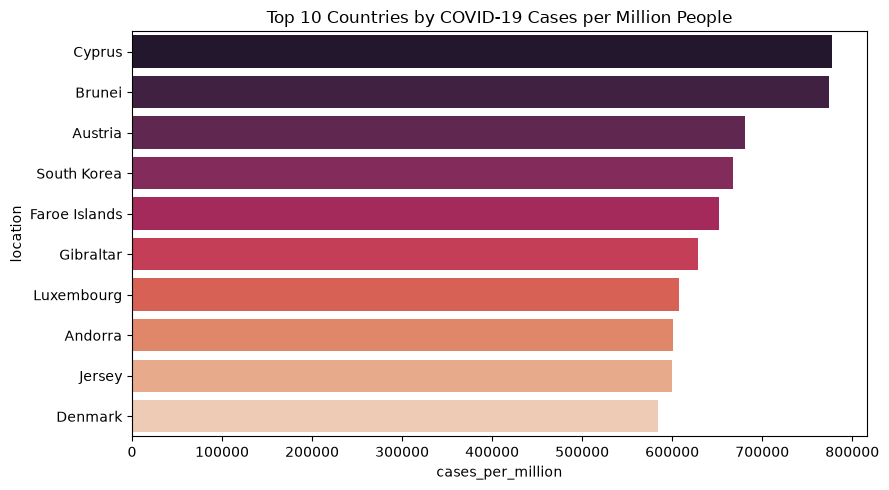

In [67]:
top10 = covid.sort_values("cases_per_million", ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(data=top10, x="cases_per_million", y="location", palette="rocket")
plt.title("Top 10 Countries by COVID-19 Cases per Million People")
plt.tight_layout()
plt.show()

In [68]:
continent_summary = covid.groupby("continent")[["total_cases", "total_deaths"]].sum()
continent_summary["death_rate_pct"] = (continent_summary["total_deaths"] / continent_summary["total_cases"]) * 100
continent_summary.sort_values("death_rate_pct", ascending=False)

,total_cases,total_deaths,death_rate_pct
continent,,,
Africa,8678568.0,187655.0,2.162281
South America,61870140.0,1098388.0,1.775312
North America,114025171.0,1315297.0,1.153515
Europe,219664613.0,1780046.0,0.810347
Asia,288967754.0,1502147.0,0.519832
Oceania,12082671.0,27250.0,0.225530


Correlation: -0.419


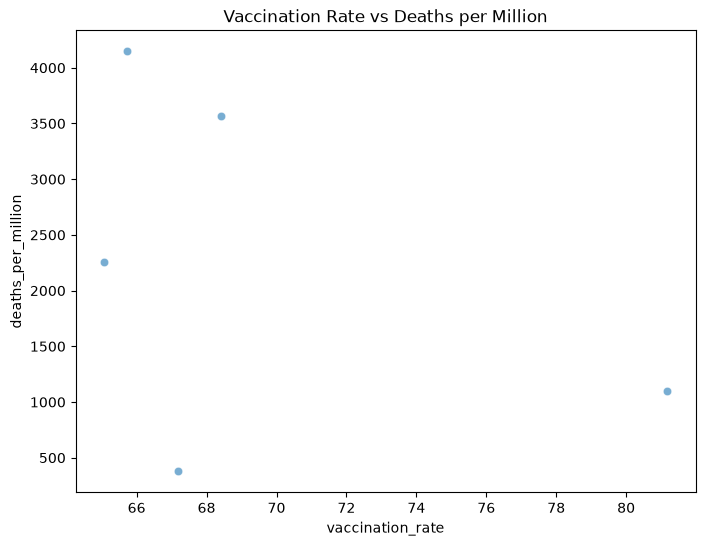

In [69]:
corr_df = covid[["vaccination_rate", "deaths_per_million"]].dropna()
correlation = corr_df["vaccination_rate"].corr(corr_df["deaths_per_million"])
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=corr_df, x="vaccination_rate", y="deaths_per_million", alpha=0.6)
plt.title("Vaccination Rate vs Deaths per Million")
plt.show()

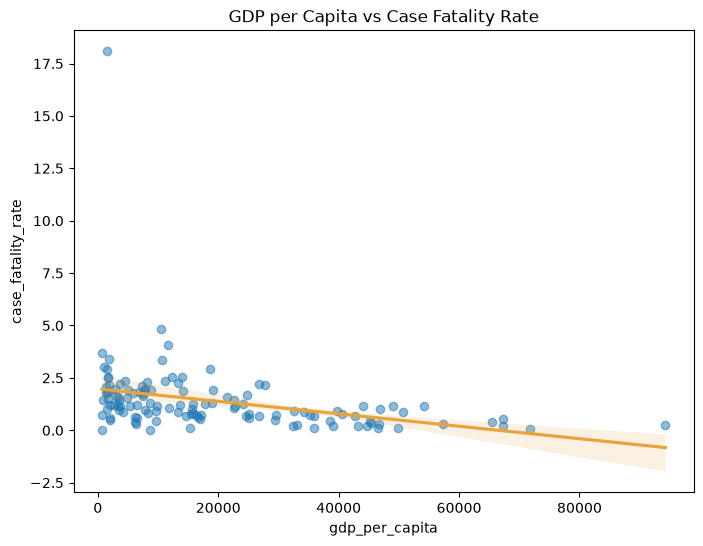

In [70]:
corr_df2 = covid[["gdp_per_capita", "case_fatality_rate"]].dropna()
corr_df2 = corr_df2[corr_df2["case_fatality_rate"] < 20]  # remove outlier noise

plt.figure(figsize=(8,6))
sns.regplot(data=corr_df2, x="gdp_per_capita", y="case_fatality_rate", 
            scatter_kws={"alpha":0.5}, line_kws={"color":"#E8A33D"})
plt.title("GDP per Capita vs Case Fatality Rate")
plt.show()

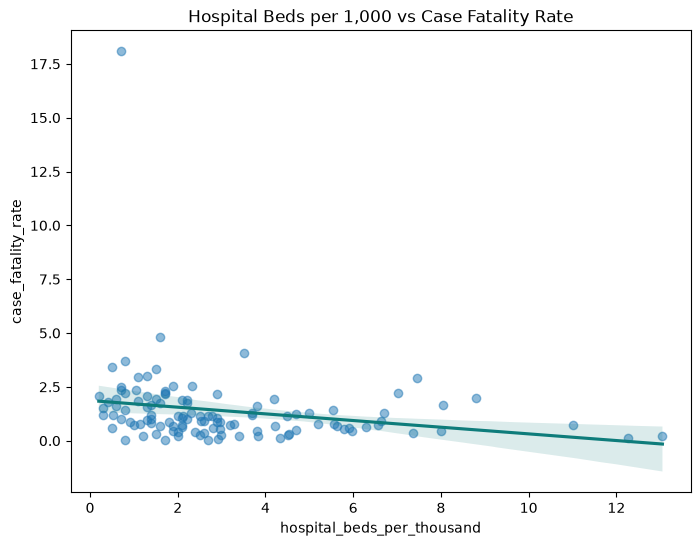

In [71]:
corr_df3 = covid[["hospital_beds_per_thousand", "case_fatality_rate"]].dropna()
corr_df3 = corr_df3[corr_df3["case_fatality_rate"] < 20]

plt.figure(figsize=(8,6))
sns.regplot(data=corr_df3, x="hospital_beds_per_thousand", y="case_fatality_rate",
            scatter_kws={"alpha":0.5}, line_kws={"color":"#0E7C7B"})
plt.title("Hospital Beds per 1,000 vs Case Fatality Rate")
plt.show()

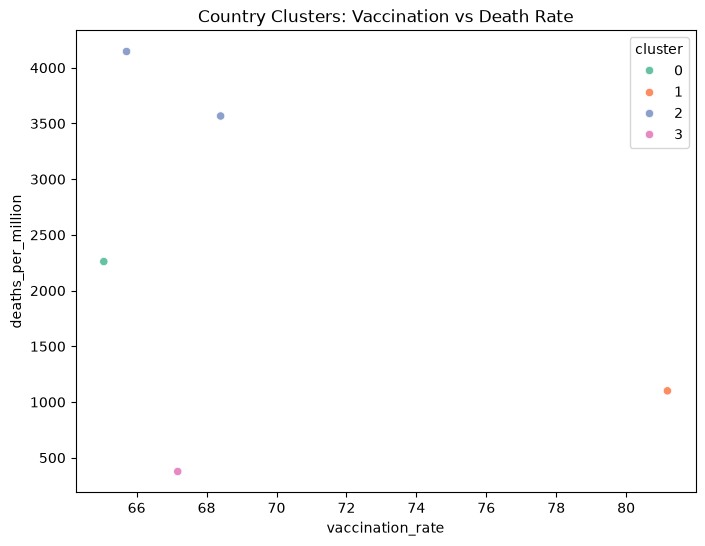

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_data = covid[["cases_per_million", "deaths_per_million", "vaccination_rate"]].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=cluster_data, x="vaccination_rate", y="deaths_per_million",
                 hue="cluster", palette="Set2")
plt.title("Country Clusters: Vaccination vs Death Rate")
plt.show()

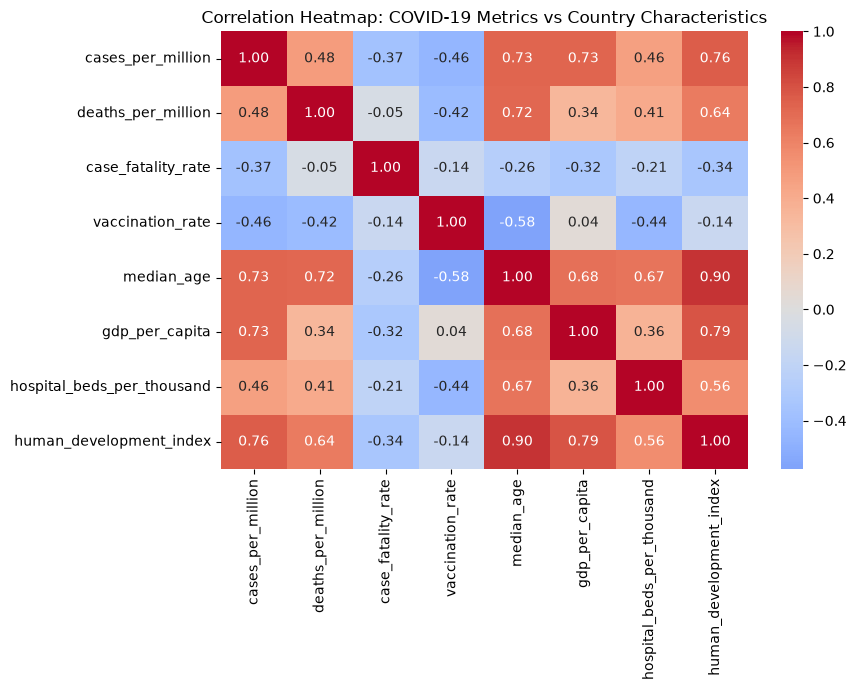

In [73]:
numeric_cols = ["cases_per_million", "deaths_per_million", "case_fatality_rate",
                 "vaccination_rate", "median_age", "gdp_per_capita",
                 "hospital_beds_per_thousand", "human_development_index"]

corr_matrix = covid[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap: COVID-19 Metrics vs Country Characteristics")
plt.tight_layout()
plt.show()

Step 1: Load and get an overview
Step 2: Clean the data
Step 3: Create rate-based columns (fairer than raw totals)
Q1 — Top 10 countries by cases per million (fairer than raw totals):
Q2 — Which continent was hit hardest?
Q3 — Does vaccination rate relate to death rate?
Q4 — Does wealth (GDP per capita) relate to case fatality rate?
Q5 — Does hospital capacity matter?
Step 4: Cluster countries by pandemic response profile
Step 5: Correlation heatmap (a strong portfolio visual)

